Цель проекта: спрогнозировать цену фьючерса на природный газ двумя методами временных рядов (ARIMA, Prophet), сравнить их точность с наивным прогнозом, и на основе исторической волатильности оценить рыночный риск позиции — Value at Risk (VaR).


Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA

Загрузка данных


Дневные цены фьючерса за 2010–2020.

In [2]:
ticker = "NG=F"
df = yf.download(ticker, start="2010-01-01", end="2020-01-01")
df.head()


/tmp/ipykernel_23819/3021526363.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2010-01-01", end="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NG=F,NG=F,NG=F,NG=F,NG=F
Date,,,,,
2010-01-04,5.884,5.894,5.705,5.705,78858
2010-01-05,5.637,5.858,5.615,5.837,99492
2010-01-06,6.009,6.075,5.650,5.690,140611
2010-01-07,5.806,6.108,5.763,6.033,135113
2010-01-08,5.749,5.853,5.621,5.827,101153


Предобработка временного ряда


Приводим индекс к календарю рабочих дней, заполнем дни без торгов, которые не попали в исходные данные. Вместо пропусков добавляем последнюю известную цену.

In [3]:
df = df['Close'].copy()
df.columns = ['price']
df.index = pd.to_datetime(df.index)
df = df.asfreq('B')
df['price'] = df['price'].ffill()
df.head()

,price
Date,
2010-01-04,5.884
2010-01-05,5.637
2010-01-06,6.009
2010-01-07,5.806
2010-01-08,5.749


Описательная статистика

In [4]:
df.describe()

,price
count,2607.000000
mean,3.303430
std,0.812402
min,1.639000
25%,2.707500
50%,3.114000
75%,3.928000
max,6.149000


EDA


Строим четыре графика для временного ряда:
- Цена
- Распределение цены
- Дневная доходность
- Скользящая волатильность

Text(0, 0.5, 'Волатильность, %')

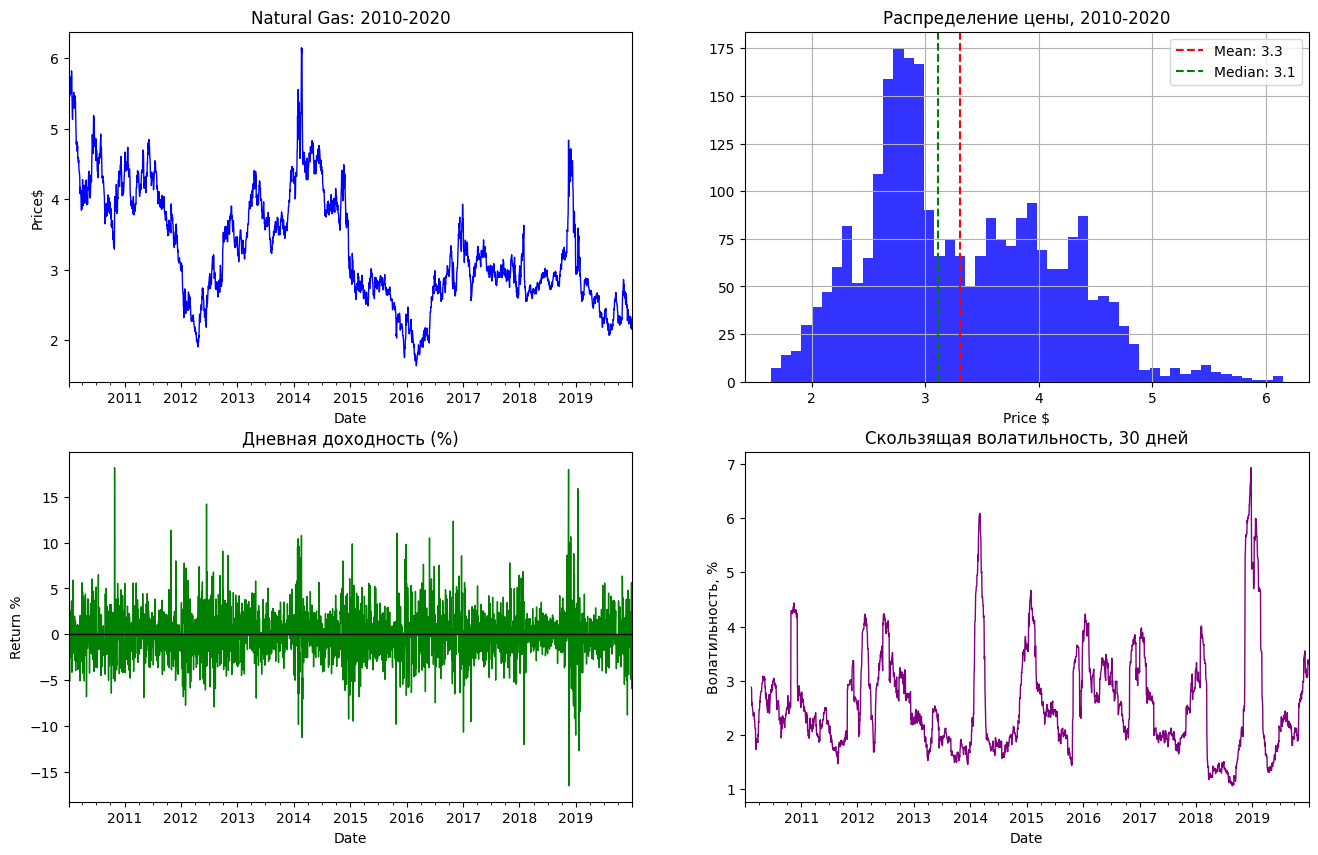

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
df['price'].plot(ax=ax, color = 'b', linewidth = 1)
ax.set_title('Natural Gas: 2010-2020')
ax.set_ylabel('Price$')
ax.set_xlabel('Date')

ax = axes[0, 1]
df['price'].hist(bins=50, ax=ax, color='b', alpha=0.8)
ax.axvline(df['price'].mean(), color='r', linestyle='--', label=f"Mean: {df['price'].mean():.1f}")
ax.axvline(df['price'].median(), color='g', linestyle='--', label=f"Median: {df['price'].median():.1f}")
ax.set_title('Распределение цены, 2010-2020')
ax.set_xlabel('Price $')
ax.legend()

ax = axes[1, 0]
df['daily_return'] = df['price'].pct_change() * 100
df['daily_return'].plot(ax=ax, color='g', linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Дневная доходность (%)')
ax.set_ylabel('Return %')

ax = axes[1, 1]
df['rolling_vol_30d'] = df['daily_return'].rolling(30).std()
df['rolling_vol_30d'].plot(ax=ax, color='purple', linewidth=1)
ax.set_title('Скользящая волатильность, 30 дней')
ax.set_ylabel('Волатильность, %')

Погодовая статистика цены

In [6]:
df['year'] = df.index.year
yearly_stats = df.groupby('year')['price'].agg(['mean', 'min', 'max', 'std']).round(2)
yearly_stats.columns = ['Mean', 'Min', 'Max', 'Std']
yearly_stats

,Mean,Min,Max,Std
year,,,,
2010,4.39,3.29,6.01,0.57
2011,4.03,2.99,4.85,0.42
2012,2.83,1.91,3.90,0.50
2013,3.73,3.11,4.46,0.33
2014,4.26,2.89,6.15,0.50
2015,2.63,1.75,3.23,0.28
2016,2.55,1.64,3.93,0.53
2017,3.02,2.56,3.72,0.18
2018,3.07,2.55,4.84,0.50


Декомпозиция временного ряда

period=252 - примерное число торговых дней в году, используем его для выделения годовой сезонности. Сезонность спроса на газ - отопительный сезон.

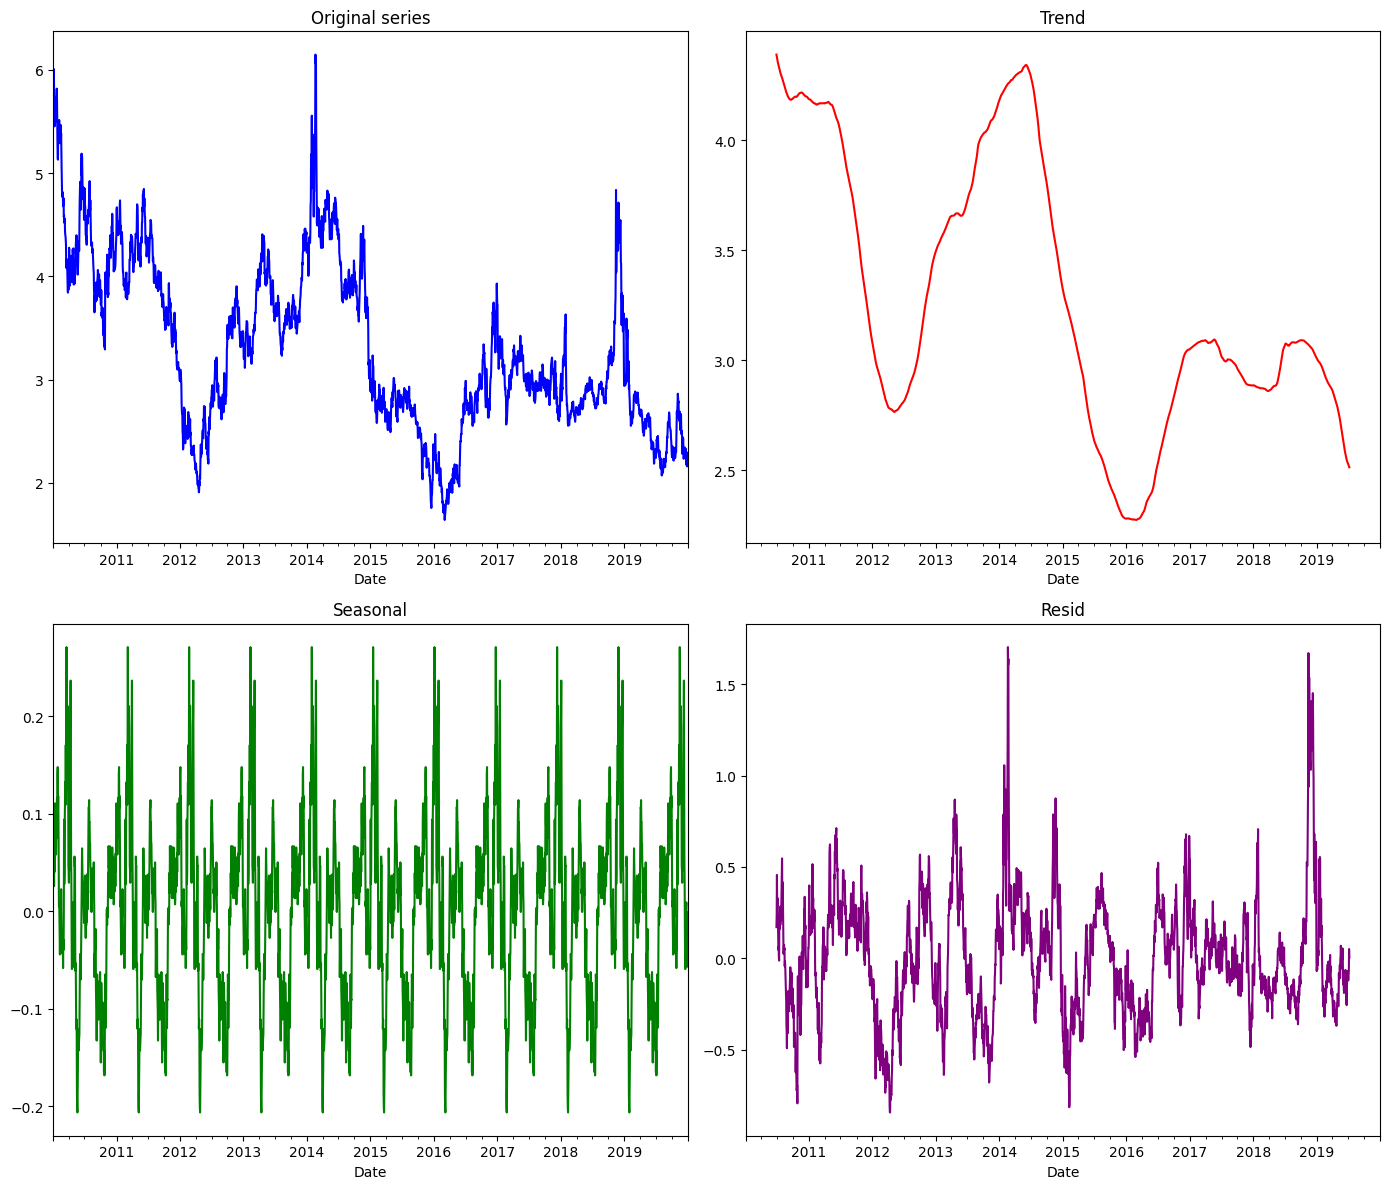

In [7]:
decomposition = seasonal_decompose(df['price'], period = 252)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]

decomposition.observed.plot(ax=ax, color='b')
ax.set_title('Original series')

ax = axes[0, 1]

decomposition.trend.plot(ax=ax, color='red')
ax.set_title('Trend')

ax = axes[1, 0]

decomposition.seasonal.plot(ax=ax, color='g')
ax.set_title('Seasonal')

ax = axes[1, 1]

decomposition.resid.plot(ax=ax, color='purple')
ax.set_title('Resid')

plt.tight_layout()
plt.show()

Проверка на стационарность

Используем сразу два теста, потому что у них противоположные нулевые гипотезы, и вместе они надёжнее одного:
- ADF: H0 = ряд нестационарен → p-value < 0.05 значит отвергаем H0.
- KPSS: H0 = ряд стационарен → p-value >= 0.05 значит не отвергаем H0.

ARIMA требует стационарности ряда, поэтому этот шаг определяет, нужно ли дифференцировать ряд перед моделированием.

In [8]:
def stationarity_test(series):

  adf_result = adfuller(series)
  adf_pval = adf_result[1]
  adf_stat = adf_pval < 0.05

  print(f"ADF Test pval: {adf_pval}")
  print(f"{"Stationary" if adf_stat else "Non-stationary"}")

  kpss_result = kpss(series)
  kpss_pvalue = kpss_result[1]
  kpss_stat = kpss_pvalue >= 0.05

  print(f"KPSS Test pvalue: {kpss_pvalue}")
  print(f"{"Stationary" if kpss_stat else "Non-stationary"}")

  return {"adf_stationary": adf_stat, "kpss_stationary": kpss_stat}

Проверяем исходный ряд цены - ожидаемо нестационарен.

In [9]:
stationarity_test(series = df['price'])

ADF Test pval: 0.010045854003933043
Stationary
KPSS Test pvalue: 0.01
Non-stationary


/tmp/ipykernel_23819/1284473406.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series)
/tmp/ipykernel_23819/1284473406.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(series)
/tmp/ipykernel_23819/1284473406.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=Tr

{'adf_stationary': True, 'kpss_stationary': np.False_}

Дифференцирование первого порядка обычно убирает тренд и делает временной ряд стационарным.

In [10]:
df['price_diff1'] = df['price'].diff()

stationarity_test(df['price_diff1'].dropna())
df['price_diff1'].dropna()

ADF Test pval: 0.0
Stationary
KPSS Test pvalue: 0.1
Stationary


/tmp/ipykernel_23819/1284473406.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series)
/tmp/ipykernel_23819/1284473406.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(series)
/tmp/ipykernel_23819/1284473406.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=Tr

,price_diff1
Date,
2010-01-05,-0.247
2010-01-06,0.372
2010-01-07,-0.203
2010-01-08,-0.057
2010-01-11,-0.295
...,...
2019-12-25,0.000
2019-12-26,0.122
2019-12-27,-0.136


ACF и PACF на стационарном ряде

Автокорреляционная (ACF) и частная автокорреляционная (PACF) функции помогают выбрать порядки AR (p) и MA (q) для ARIMA - резкий обрыв в PACF после лага k подсказывает AR(k), резкий обрыв в ACF подсказывает MA(k).

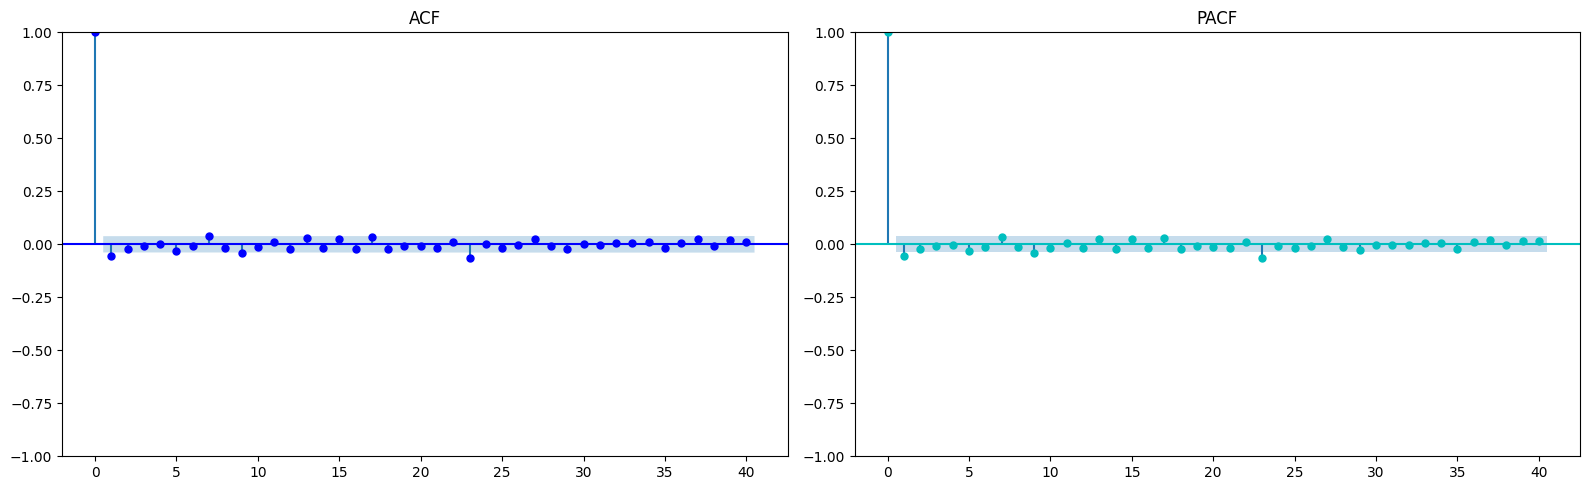

In [11]:
stationary_series = df['price_diff1'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(stationary_series, lags=40, ax=axes[0], color='b')
axes[0].set_title('ACF')

plot_pacf(stationary_series, lags=40, ax=axes[1], color='c', method='ywm')
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

Разбиение на train/test


Тестовый период — последние 251 торговый день (1 календарный год).

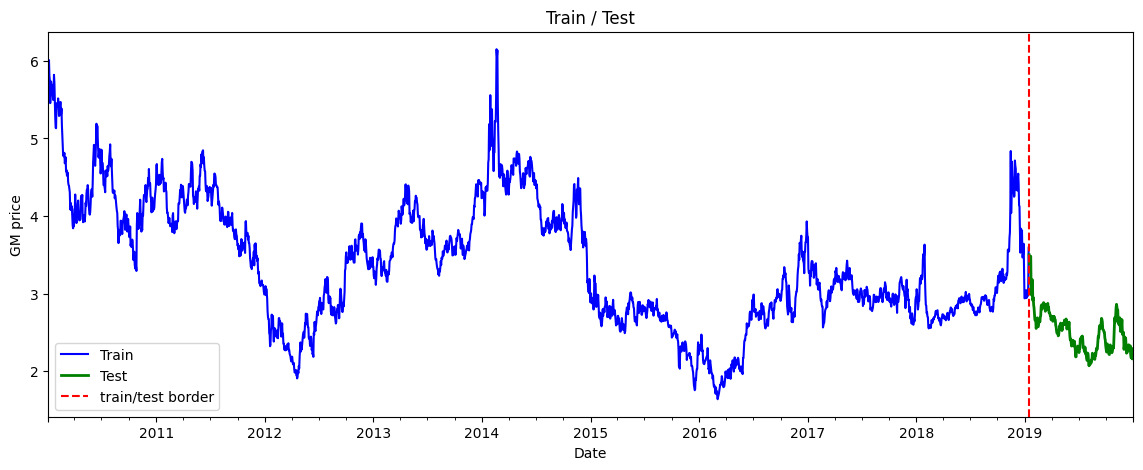

In [12]:
TEST_SIZE = 251
train = df['price'].iloc[:-TEST_SIZE]
test = df['price'].iloc[-TEST_SIZE:]

plt.figure(figsize=(14, 5))
train.plot(label='Train', color='b')
test.plot(label='Test', color='g', linewidth=2)
plt.axvline(x=train.index[-1], color='r', linestyle='--', label='train/test border')
plt.title('Train / Test')
plt.legend()
plt.ylabel('GM price')
plt.show()

Подбор параметров ARIMA(p,1,q) по AIC


d=1 фиксируем по результату теста на стационарность выше (одного дифференцирования достаточно). Перебираем `p` и `q` от 0 до 3 и выбираем модель с наименьшим AIC.

In [13]:
from itertools import product

best_aic = np.inf
best_order = None
results_list = []

p_range = range(0, 4)
d_range = [1]
q_range = range(0, 4)

print('Подбор параметров ARIMA...')

for p, d, q in product(p_range, d_range, q_range):
    try:
        model = ARIMA(train, order=(p, d, q))
        result = model.fit()
        aic = result.aic
        results_list.append({'p': p, 'd': d, 'q': q, 'AIC': round(aic, 2)})
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
    except Exception:
        pass

results_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)
print(f'\n Лучший порядок: ARIMA{best_order} с AIC = {best_aic:.2f}')
print('\nТоп-5 по AIC:')
results_df.head()

Подбор параметров ARIMA...


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible sta


 Лучший порядок: ARIMA(0, 1, 1) с AIC = -4243.54

Топ-5 по AIC:


,p,d,q,AIC
0,0,1,1,-4243.54
1,1,1,0,-4243.32
2,1,1,1,-4242.23
3,0,1,2,-4241.96
4,2,1,0,-4241.88


Обучение на лучших параметрах

In [14]:
final_model = ARIMA(train, order=(1,1,1))
res = final_model.fit()
print(res.summary())


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                 2356
Model:                 ARIMA(1, 1, 1)   Log Likelihood                2124.117
Date:                Wed, 16 Sep 2026   AIC                          -4242.235
Time:                        23:17:31   BIC                          -4224.942
Sample:                    01-04-2010   HQIC                         -4235.938
                         - 01-14-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2850      0.219      1.299      0.194      -0.145       0.715
ma.L1         -0.3427      0.214     -1.599      0.110      -0.763       0.077
sigma2         0.0096      0.000     73.206      0.0

Прогноз ARIMA и визуализация

Строим точечный прогноз на весь тестовый период (251 день) и 95%-й доверительный интервал.

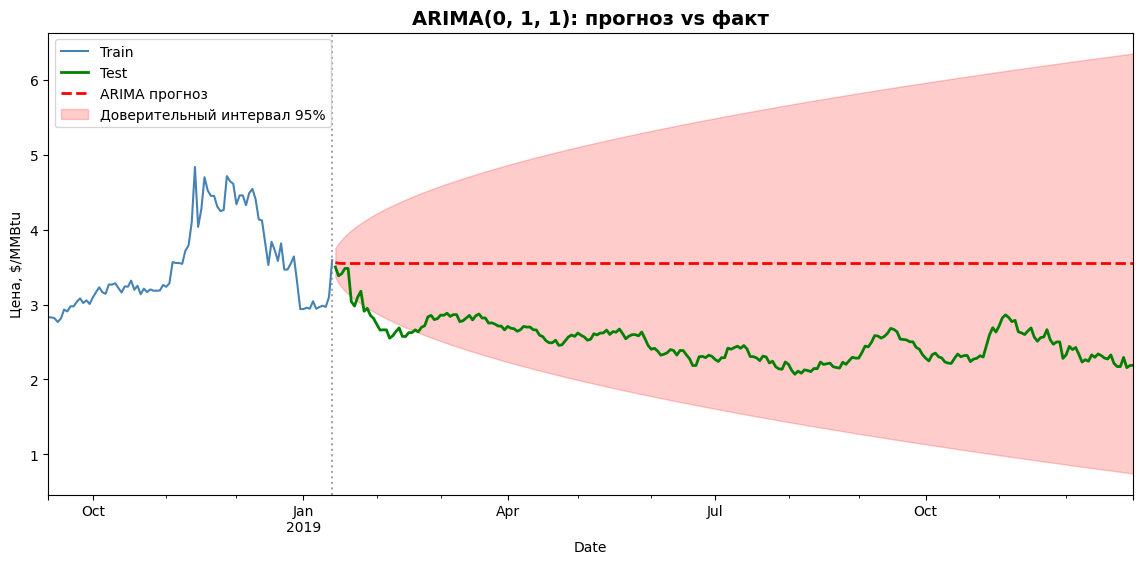

In [15]:
arima_forecast = res.forecast(steps=TEST_SIZE)
arima_conf_int = res.get_forecast(steps=TEST_SIZE).conf_int(alpha=0.05)

plt.figure(figsize=(14, 6))
train[-90:].plot(label='Train', color='steelblue')
test.plot(label='Test', color='green', linewidth=2)
arima_forecast.plot(label='ARIMA прогноз', color='red', linewidth=2, linestyle='--')

plt.fill_between(
    arima_conf_int.index,
    arima_conf_int.iloc[:, 0],
    arima_conf_int.iloc[:, 1],
    alpha=0.2, color='red', label='Доверительный интервал 95%'
)

plt.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title(f'ARIMA{best_order}: прогноз vs факт', fontsize=14, fontweight='bold')
plt.ylabel('Цена, $/MMBtu')
plt.legend()
plt.show()

Prophet

In [16]:
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error


prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

Прогноз Prophet и визуализация

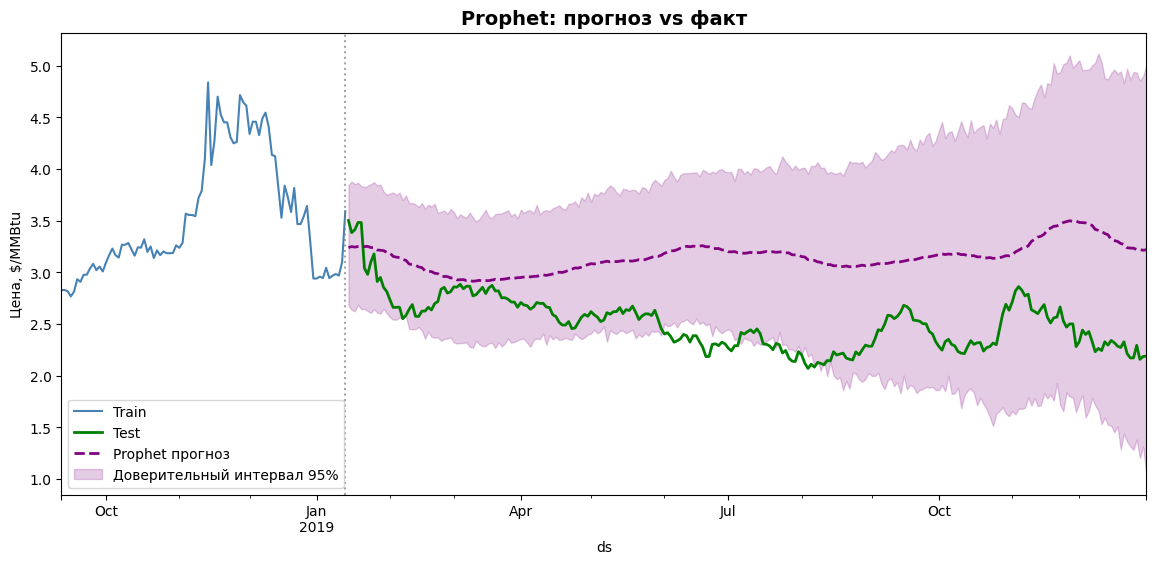

In [17]:
future = prophet_model.make_future_dataframe(periods=TEST_SIZE, freq='B')
prophet_forecast_df = prophet_model.predict(future)

prophet_pred = prophet_forecast_df.set_index('ds')['yhat'].iloc[-TEST_SIZE:]
prophet_lower = prophet_forecast_df.set_index('ds')['yhat_lower'].iloc[-TEST_SIZE:]
prophet_upper = prophet_forecast_df.set_index('ds')['yhat_upper'].iloc[-TEST_SIZE:]

plt.figure(figsize=(14, 6))
train[-90:].plot(label='Train', color='steelblue')
test.plot(label='Test', color='green', linewidth=2)
prophet_pred.plot(label='Prophet прогноз', color='purple', linewidth=2, linestyle='--')

plt.fill_between(
    prophet_lower.index,
    prophet_lower.values,
    prophet_upper.values,
    alpha=0.2, color='purple', label='Доверительный интервал 95%'
)

plt.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title('Prophet: прогноз vs факт', fontsize=14, fontweight='bold')
plt.ylabel('Цена, $/MMBtu')
plt.legend()
plt.show()

Последнее значение

Прежде чем доверять ARIMA/Prophet, построим наивный прогноз, что цена не изменится.

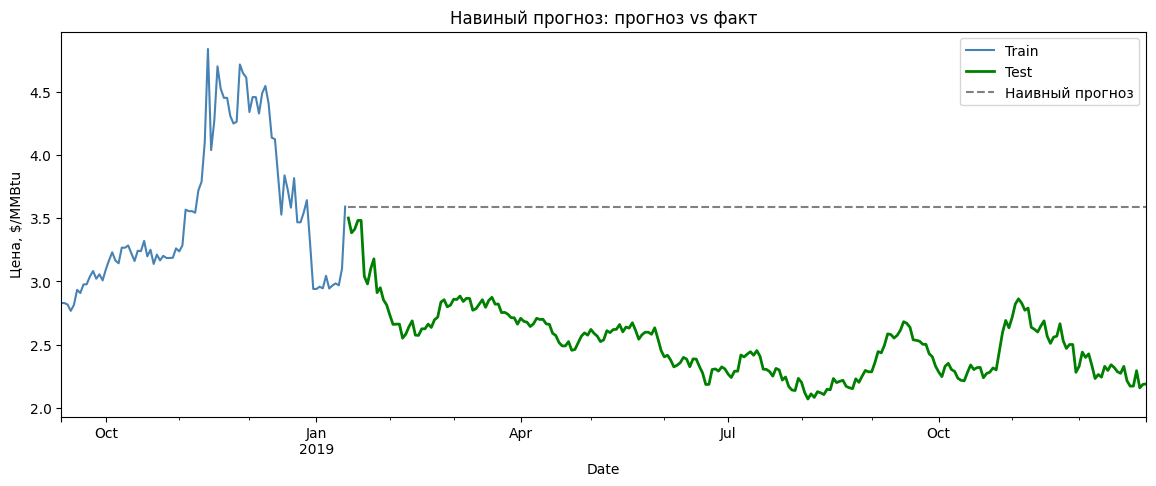

In [18]:
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

plt.figure(figsize=(14, 5))
train[-90:].plot(label='Train', color='steelblue')
test.plot(label='Test', color='green', linewidth=2)
naive_forecast.plot(label='Наивный прогноз', color='gray', linestyle='--')
plt.title('Навиный прогноз: прогноз vs факт')
plt.ylabel('Цена, $/MMBtu')
plt.legend()
plt.show()


Метрики и сравнение моделей


Возьмем три стандартные метрики:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

In [19]:
def forecast_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true.values - y_pred.values) / y_true.values)) * 100
    return {"model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "MAPE_%": round(mape, 2)}


metrics_summary = pd.DataFrame([
    forecast_metrics(test, naive_forecast, "Naive (persistence)"),
    forecast_metrics(test, arima_forecast, f"ARIMA{best_order}"),
    forecast_metrics(test, prophet_pred, "Prophet"),
]).sort_values("MAE")

display(metrics_summary)


,model,MAE,RMSE,MAPE_%
2,Prophet,0.6473,0.7150,27.13
1,"ARIMA(0, 1, 1)",1.0395,1.0718,42.89
0,Naive (persistence),1.0826,1.1138,44.63


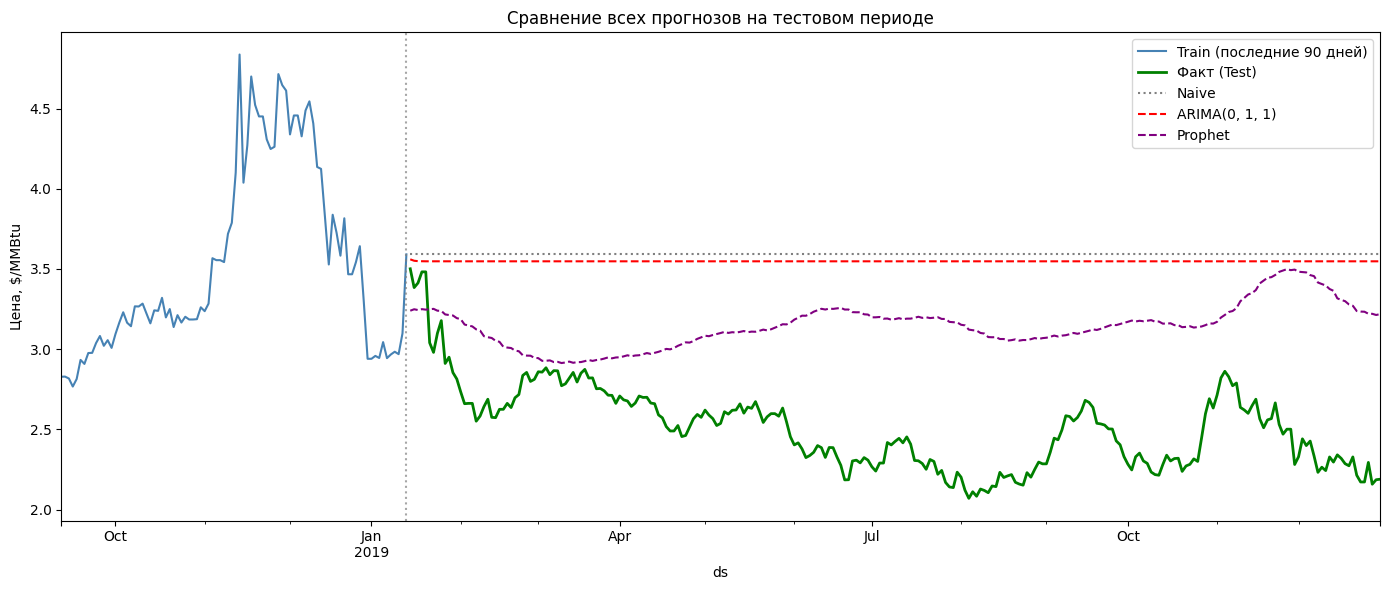

In [20]:
plt.figure(figsize=(14, 6))
train[-90:].plot(label='Train (последние 90 дней)', color='steelblue')
test.plot(label='Факт (Test)', color='green', linewidth=2)
naive_forecast.plot(label='Naive', color='gray', linestyle=':')
arima_forecast.plot(label=f'ARIMA{best_order}', color='red', linestyle='--')
prophet_pred.plot(label='Prophet', color='purple', linestyle='--')
plt.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title('Сравнение всех прогнозов на тестовом периоде')
plt.ylabel('Цена, $/MMBtu')
plt.legend()
plt.tight_layout()
plt.show()


Мы можем увидеть, что в отличие от ARIMA, Prophet довольно неплохо угадывает общий тренд. ARIMA же практически повторяет последний прогноз, что неудовлитворительно, но предсказуемо, так как ARIMA плохо справляется с предсказаниями на столь дальний горизонт, а также любит более выраженную сезонность в данных.

VaR и волатильность


Считаем VaR двумя методами на train:

- Параметрический: предполагаем, что доходности нормально распределены, и берём квантиль нормального распределения.
- Исторический: берём эмпирический квантиль исторических доходностей напрямую, без предположения о форме распределения.

In [21]:
from scipy import stats

returns_train = df.loc[train.index, 'daily_return'].dropna()
returns_test = df.loc[test.index, 'daily_return'].dropna()

print('Статистика дневных доходностей (train):')
print(returns_train.describe())

CONFIDENCE_LEVELS = [0.95, 0.99]
var_results = []

mu, sigma = returns_train.mean(), returns_train.std()

for cl in CONFIDENCE_LEVELS:
    z = stats.norm.ppf(1 - cl)
    var_parametric = -(mu + z * sigma)
    var_historical = -np.percentile(returns_train, (1 - cl) * 100)

    var_results.append({
        "confidence": f"{int(cl*100)}%",
        "VaR_parametric_%": round(var_parametric, 3),
        "VaR_historical_%": round(var_historical, 3),
    })

var_df = pd.DataFrame(var_results)
display(var_df)


Статистика дневных доходностей (train):
count    2355.000000
mean        0.017415
std         2.778895
min       -16.518499
25%        -1.588773
50%         0.000000
75%         1.468049
max        18.165250
Name: daily_return, dtype: float64


,confidence,VaR_parametric_%,VaR_historical_%
0,95%,4.553,4.112
1,99%,6.447,6.642


Интерпретация: VaR 95% - значение в таблице означает, что с вероятностью 95% дневной убыток по позиции не превысит эту величину (в % от цены).

Бэктестинг VaR


Используем тест Купика, чтобы понять насколько фактическая частота отличается от ожидаемой по VaR.


In [25]:
def kupiec_test(returns, var_series_pct, confidence):
    p = 1 - confidence
    violations = (returns < -var_series_pct).sum()
    n = len(returns)
    viol_rate = violations / n

    if viol_rate in (0, 1):
        lr_stat = np.nan
        p_value = np.nan
    else:
        lr_stat = -2 * np.log(
            ((1 - p) ** (n - violations) * p ** violations) /
            ((1 - viol_rate) ** (n - violations) * viol_rate ** violations)
        )
        p_value = 1 - stats.chi2.cdf(lr_stat, df=1)

    return {
        "confidence": f"{int(confidence*100)}%",
        "violations": violations,
        "total_days": n,
        "violation_rate": round(viol_rate, 4),
        "expected_rate": p,
        "kupiec_LR": round(lr_stat, 3) if not np.isnan(lr_stat) else None,
        "kupiec_pvalue": round(p_value, 3) if not np.isnan(p_value) else None,
        "verdict": "не отвергаем H0" if (not np.isnan(p_value) and p_value > 0.05)
                    else "отвергаем H0"
    }


backtest_results = []
for cl in CONFIDENCE_LEVELS:
    var_hist_pct = -np.percentile(returns_train, (1 - cl) * 100)
    backtest_results.append(kupiec_test(returns_test, var_hist_pct, cl))

backtest_df = pd.DataFrame(backtest_results)
display(backtest_df)


,confidence,violations,total_days,violation_rate,expected_rate,kupiec_LR,kupiec_pvalue,verdict
0,95%,12,251,0.0478,0.05,0.026,0.873,не отвергаем H0
1,99%,3,251,0.0120,0.01,0.091,0.763,не отвергаем H0


Expected Shortfall (CVaR)


CVaR поможет нам оценить насколько большим будет ожидаемый убыток в случае выхода за 95% доверительный интервал.

In [26]:
for cl in CONFIDENCE_LEVELS:
    threshold = np.percentile(returns_train, (1 - cl) * 100)
    es = -returns_train[returns_train <= threshold].mean()
    print(f"Expected Shortfall {int(cl*100)}%: {es:.3f}% в день (в среднем в худших {int((1-cl)*100)}% дней)")


Expected Shortfall 95%: 5.856% в день (в среднем в худших 5% дней)
Expected Shortfall 99%: 8.913% в день (в среднем в худших 1% дней)


Визуализация: доходности test-периода vs порог VaR

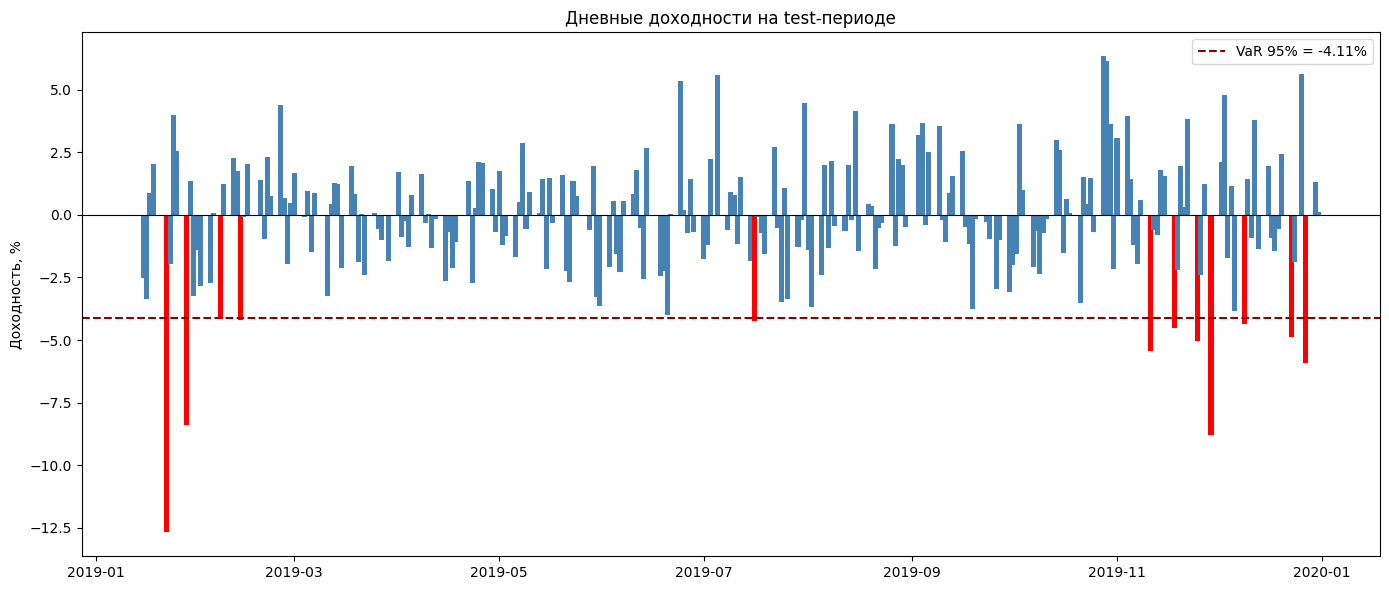

In [28]:
var95_hist = -np.percentile(returns_train, 5)

plt.figure(figsize=(14, 6))
colors = np.where(returns_test < -var95_hist, 'red', 'steelblue')
plt.bar(returns_test.index, returns_test.values, color=colors, width=1.5)
plt.axhline(-var95_hist, color='darkred', linestyle='--', label=f'VaR 95% = -{var95_hist:.2f}%')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Дневные доходности на test-периоде')
plt.ylabel('Доходность, %')
plt.legend()
plt.tight_layout()
plt.show()


Итоговые выводы проекта

- Prophet обходят наивный бейзлайн по всем трём метрикам и хорошо угадывает тренд.
- ARIMA, плохо справляется с задачей в связи со слишком обширным горизонтом предсказания.
- MAPE на горизонте в год остаётся высоким (25-35%)
VaR:
- Бэктест на тестовом периоде прошёл тест Купика - фактическая частота нарушений VaR статистически не отличается значимо от ожидаемой, модель адекватна для оценки риска на этом периоде


